##### Clusters de risco (prevenção de defasagem)
- Features: Defasagem, Fase vs Fase ideal, IDA, IEG, IPS, IAN, IPV. 

##### Dicionário Dados Datathon
- Algoritmos: KMeans / HDBSCAN 

##### Perguntas
- Quais grupos têm sinais de risco “silencioso” (ex.: notas ok, mas IPS/IEG ruins)?
- Existem clusters onde a defasagem é alta mesmo com INDE razoável (alerta de inconsistência/viés)?

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

df = pd.read_csv("base_dados_pede_2024_ajustado.csv")

k=5 | inertia=4170.6460

Tamanhos dos clusters:
cluster5
0    104
1    169
2     69
3    339
4    179
Name: count, dtype: int64

=== Cartão do Cluster (k=5) ===
            n   pv_rate  defasagem_media  gap_fase_medio  inde_medio  ida_media  ieg_media  ips_media  ian_media  ipv_medio
cluster5                                                                                                                   
0         104  0.201923        -1.538462        1.538462    7.092433   6.422115   7.902885   6.918269   4.735577   7.597096
1         169  0.000000        -1.437870        1.461538    5.502130   3.456213   5.673373   6.675148   5.103550   5.937692
3         339  0.144543        -1.247788        1.247788    7.287236   6.900295   8.610029   6.987021   4.985251   7.614897
2          69  0.101449         0.028986        1.971014    7.763145   7.297101   8.185507   7.207246  10.000000   7.543928
4         179  0.201117         0.072626       -0.072626    7.696134   6.397765   8.503352   6.

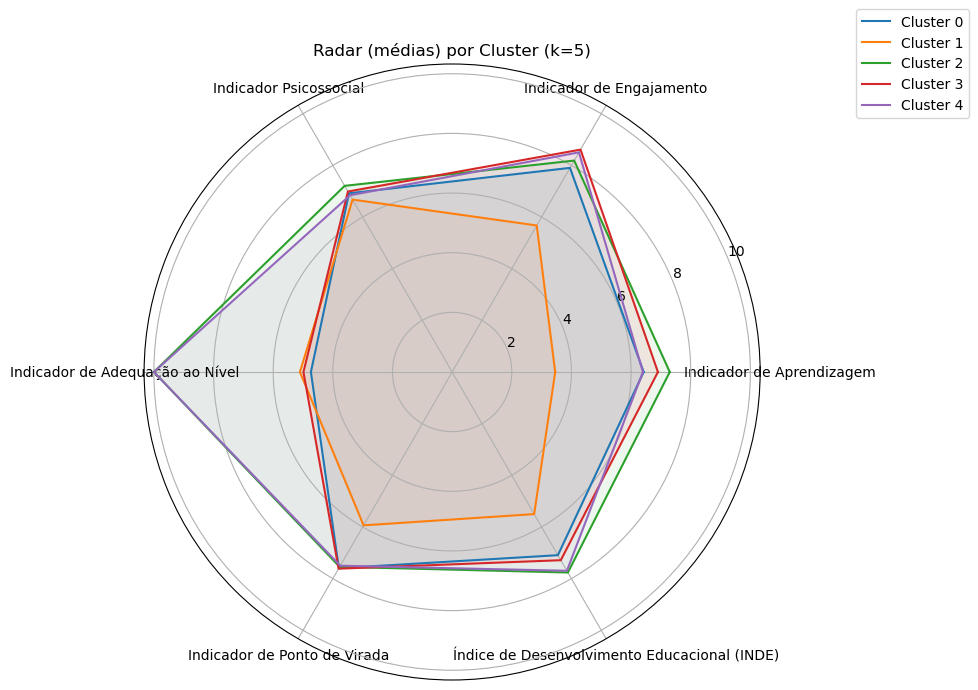


=== Simulação (Cluster 1) ===
INDE base: 5.502 -> INDE estimado: 6.210
Detalhes:
- Indicador de Aprendizagem: 3.46 -> 6.00 | Δ=2.54 | peso=0.20 | contrib=0.509
- Indicador de Engajamento: 5.67 -> 7.00 | Δ=1.33 | peso=0.15 | contrib=0.199

Arquivos gerados:
- results/cluster_card_risco_k5.csv
- results/base_com_clusters_k5.csv
- results/cluster_feature_zmeans_k5.csv
- results/cluster_feature_importance_absz_k5.csv
Salvo modelo: model/model.pkl


In [ ]:
import pickle
from processing_and_models import parse_fase_ideal
from processing_and_models import normalize_bool_sim_nao
from processing_and_models import standardize_numpy
from processing_and_models import kmeans_numpy
from processing_and_models import simulate_cluster_impact
from processing_and_models import predict_kmeans_model


# helpers

def plot_radar(cluster_means_raw, features, title="Radar dos Clusters"):
    """
    (Aluno) Cria um gráfico radar simples para comparar médias por cluster.
    - cluster_means_raw: DataFrame index=cluster, cols=features
    - features: lista de nomes de colunas a plotar
    - title: título do gráfico (opcional)
    """
    labels = cluster_means_raw.index.astype(str).tolist()
    num_vars = len(features)

    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    for c in cluster_means_raw.index:
        values = cluster_means_raw.loc[c, features].tolist()
        values += values[:1]
        ax.plot(angles, values, label=f"Cluster {c}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10))
    plt.title(title)
    plt.show()

# preparo de features

df["Fase_ideal_num"] = df["Fase ideal"].apply(parse_fase_ideal)
df["gap_fase"] = df["Fase_ideal_num"] - df["Fase"]
df["pv_bool"] = normalize_bool_sim_nao(df["Atingiu Ponto de Virada"])

risk_cols = [
    "Nível de Defasagem",
    "Fase",
    "Fase_ideal_num",
    "gap_fase",
    "Indicador de Aprendizagem",
    "Indicador de Engajamento",
    "Indicador Psicossocial",
    "Indicador de Adequação ao Nível",
    "Indicador de Ponto de Virada",
    "Índice de Desenvolvimento Educacional (INDE)",
]

missing = [c for c in risk_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltam colunas no df: {missing}")

X_df = df[risk_cols].copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce")
X_df = X_df.fillna(X_df.mean(numeric_only=True))

X = X_df.to_numpy(dtype=float)
X_scaled, mu, sigma = standardize_numpy(X)

# treinamento KMeans (k=5)

k = 5
labels, centroids, inertia = kmeans_numpy(X_scaled, k=k, n_init=40, max_iter=700, seed=42)
df["cluster5"] = labels

print(f"k=5 | inertia={inertia:.4f}")
print("\nTamanhos dos clusters:")
print(df["cluster5"].value_counts().sort_index())

cluster_card5 = (
    df.groupby("cluster5")
      .agg(
          n=("RA", "count"),
          pv_rate=("pv_bool", "mean"),
          defasagem_media=("Nível de Defasagem", "mean"),
          gap_fase_medio=("gap_fase", "mean"),
          inde_medio=("Índice de Desenvolvimento Educacional (INDE)", "mean"),
          ida_media=("Indicador de Aprendizagem", "mean"),
          ieg_media=("Indicador de Engajamento", "mean"),
          ips_media=("Indicador Psicossocial", "mean"),
          ian_media=("Indicador de Adequação ao Nível", "mean"),
          ipv_medio=("Indicador de Ponto de Virada", "mean"),
      )
      .sort_values(["defasagem_media", "pv_rate"], ascending=[True, True]) # mais negativo é mais defasado (pior)
)

print("\n=== Cartão do Cluster (k=5) ===")
print(cluster_card5.to_string())

# Feature importance por cluster
# z-score médio por cluster (quanto mais distante de 0, mais característico)

X_scaled_df = pd.DataFrame(X_scaled, columns=risk_cols)
X_scaled_df["cluster5"] = df["cluster5"].values

z_means = X_scaled_df.groupby("cluster5")[risk_cols].mean()

# "importância" = |z| (distância do padrão geral)
z_importance = z_means.abs()

print("\n=== Top features (|z|) por cluster ===")
for c in z_importance.index:
    top = z_importance.loc[c].sort_values(ascending=False).head(5)
    print(f"\nCluster {c} - Top 5 features:")
    for feat, val in top.items():
        direction = "↑" if z_means.loc[c, feat] > 0 else "↓"
        print(f"  {feat}: {direction} (|z|={val:.2f}, z={z_means.loc[c, feat]:.2f})")

z_means.to_csv("results/cluster_feature_zmeans_k5.csv", index=True)
z_importance.to_csv("results/cluster_feature_importance_absz_k5.csv", index=True)

radar_features = [
    "Indicador de Aprendizagem",
    "Indicador de Engajamento",
    "Indicador Psicossocial",
    "Indicador de Adequação ao Nível",
    "Indicador de Ponto de Virada",
    "Índice de Desenvolvimento Educacional (INDE)",
]

cluster_means_raw = df.groupby("cluster5")[radar_features].mean()
plot_radar(cluster_means_raw, radar_features, title="Radar (médias) por Cluster (k=5)")

#  simulação de impacto no Cluster 1, como INDE é composto por indicadores (aprox), ajustar IDA e IEG e estima impacto aproximado em INDE.

# cenário: melhorar Cluster 1 (o que no seu resultado é o cluster com PV 0)
# Se no seu caso o "cluster crítico" não for 1, troque aqui.
cluster_critico = 1

# pesos conservadores (ajuste livre)
weights = {
    "Indicador de Aprendizagem": 0.20,
    "Indicador de Engajamento": 0.15,
    "Indicador Psicossocial": 0.10,
    "Indicador de Adequação ao Nível": 0.15,
    "Indicador de Ponto de Virada": 0.15,
}

# cenário 1: elevar IDA para 6 e IEG para 7
scenario = {
    "Indicador de Aprendizagem": 6.0,
    "Indicador de Engajamento": 7.0,
}

inde_base, inde_new, details = simulate_cluster_impact(cluster_critico, scenario, weights)

print(f"\n=== Simulação (Cluster {cluster_critico}) ===")
print(f"INDE base: {inde_base:.3f} -> INDE estimado: {inde_new:.3f}")
print("Detalhes:")
for feat, cur, tgt, delta, w, contrib in details:
    print(f"- {feat}: {cur:.2f} -> {tgt:.2f} | Δ={delta:.2f} | peso={w:.2f} | contrib={contrib:.3f}")

# salvar saídas

cluster_card5.to_csv("results/cluster_card_risco_k5.csv", index=True)
df.to_csv("results/base_com_clusters_k5.csv", index=False)

print("\nArquivos gerados:")
print("- results/cluster_card_risco_k5.csv")
print("- results/base_com_clusters_k5.csv")
print("- results/cluster_feature_zmeans_k5.csv")
print("- results/cluster_feature_importance_absz_k5.csv")

# salvar modelo KMeans (centroids + scaler) para uso futuro

os.makedirs("results", exist_ok=True)
model = {
    "centroids": centroids,
    "mu": mu.tolist(),
    "sigma": sigma.tolist(),
    "risk_cols": risk_cols,
    "k": k,
    "inertia": float(inertia),
}
model_path = "model/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Salvo modelo: {model_path}")

# Exemplo de uso (comentado):
# new_df = pd.read_csv('novos_alunos.csv')
# labels_pred = predict_kmeans_model(new_df, model)

In [3]:
for c in sorted(df["cluster5"].unique()):
    df[df["cluster5"] == c].to_csv(f"results/cluster_{c}_alunos.csv", index=False)

In [4]:
risk_vars = [
    "Nível de Defasagem",
    "Indicador de Aprendizagem",
    "Indicador de Engajamento",
    "Indicador de Ponto de Virada"
]

risk_df = df[risk_vars].copy()
risk_df = risk_df.apply(pd.to_numeric, errors="coerce")
risk_df = risk_df.fillna(risk_df.mean())

mu = risk_df.mean()
sigma = risk_df.std()
risk_z = (risk_df - mu) / sigma

risk_z["defasagem_risco"] = -risk_z["Nível de Defasagem"]

df["risk_score"] = (
    0.35 * risk_z["defasagem_risco"] +
    0.30 * (-risk_z["Indicador de Aprendizagem"]) +
    0.20 * (-risk_z["Indicador de Engajamento"]) +
    0.15 * (-risk_z["Indicador de Ponto de Virada"])
)

df["risk_score"] += (~df["pv_bool"]).astype(int) * 0.3

top_por_cluster = {}

for c in sorted(df["cluster5"].unique()):
    top = (
        df[df["cluster5"] == c]
        .sort_values("risk_score", ascending=False)
        .head(10)
    )
    top_por_cluster[c] = top

    print(f"\nTop 10 alunos que merecem atenção maior - Cluster {c}")
    print(top[[
        "RA",
        "Nome",
        "Nível de Defasagem",
        "Indicador de Aprendizagem",
        "Indicador de Engajamento",
        "Indicador de Ponto de Virada",
        "risk_score"
    ]])

# Salva arquivos por cluster e um arquivo combinado

os.makedirs("results", exist_ok=True)
combined = pd.concat(list(top_por_cluster.values()), ignore_index=True) if len(top_por_cluster) > 0 else pd.DataFrame()
combined.to_csv("results/top_alunos_necessita_atencao_por_cluster.csv", index=False)
print("Salvo: results/top_alunos_necessita_atencao_por_cluster.csv")


Top 10 alunos que merecem atenção maior - Cluster 0
         RA       Nome  Nível de Defasagem  Indicador de Aprendizagem  \
103  RA-104  Aluno-104                  -4                        3.7   
59    RA-60   Aluno-60                  -3                        4.9   
301  RA-302  Aluno-302                  -3                        4.8   
107  RA-108  Aluno-108                  -3                        5.0   
181  RA-182  Aluno-182                  -3                        4.1   
45    RA-46   Aluno-46                  -2                        2.1   
94    RA-95   Aluno-95                  -2                        4.8   
5      RA-6    Aluno-6                  -1                        3.3   
48    RA-49   Aluno-49                  -2                        3.9   
0      RA-1    Aluno-1                  -1                        4.0   

     Indicador de Engajamento  Indicador de Ponto de Virada  risk_score  
103                       8.7                         6.708    1.8922

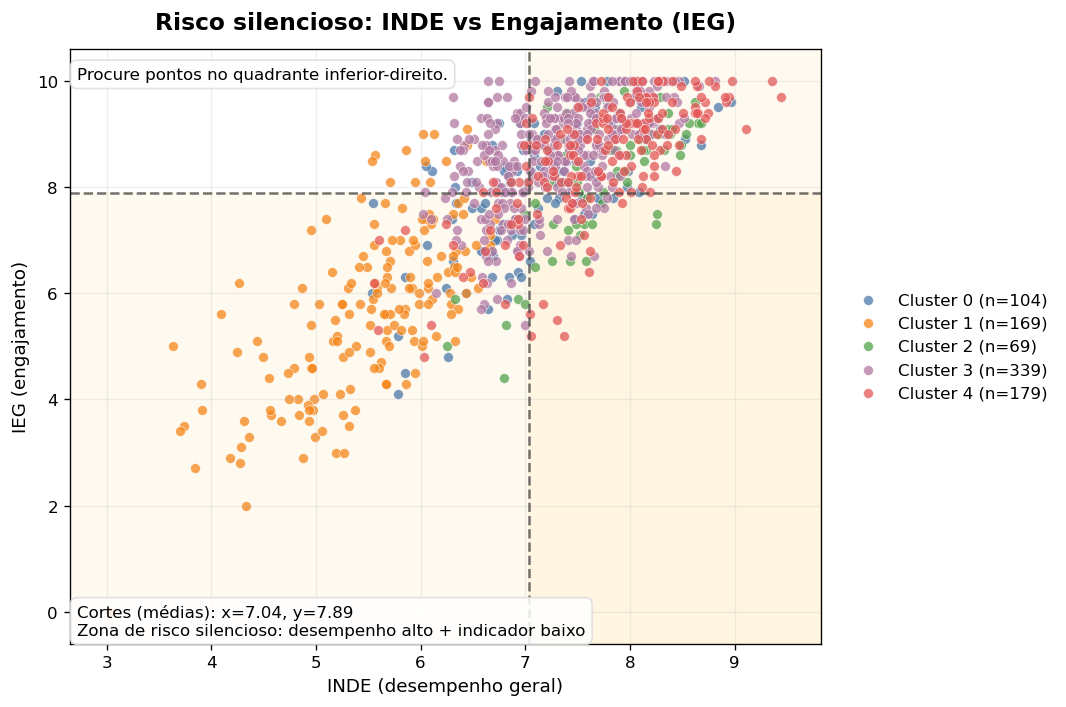

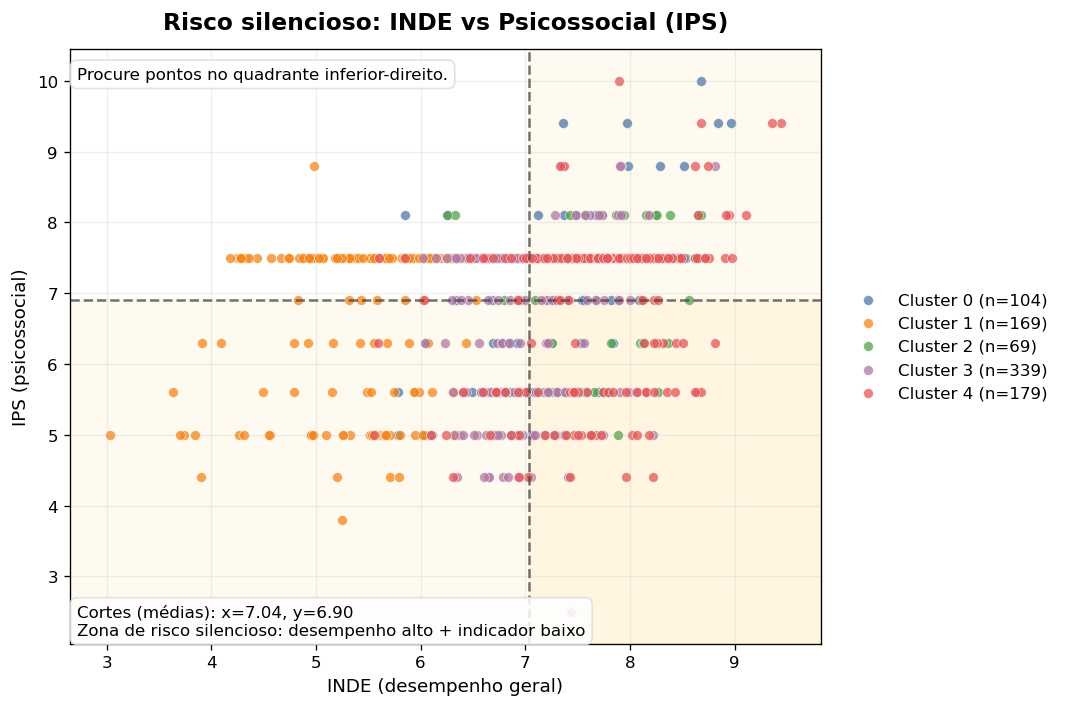

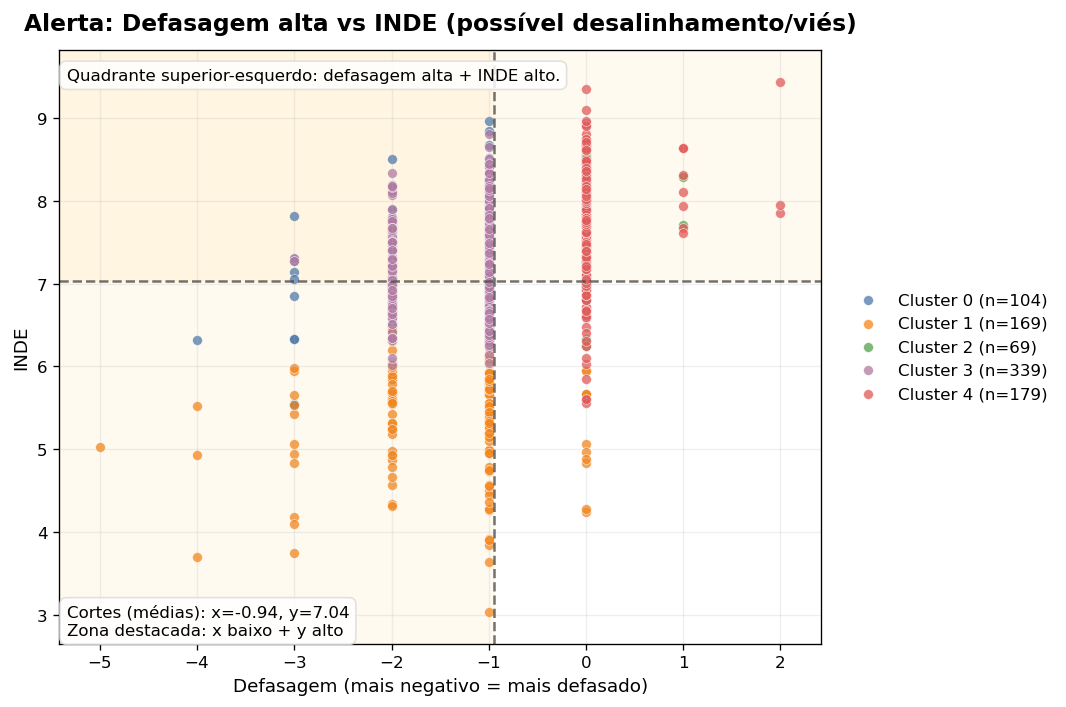

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


CLUSTER_COLORS = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#54A24B",
    3: "#B279A2",
    4: "#E45756",
}

def plot_quadrant_scatter(
    df, x_col, y_col, cluster_col="cluster5",
    title="", x_label="", y_label="",
    highlight_quadrant="bottom_right",
    note=""
):
    """
    (Aluno) Plota um scatter dividido em quadrantes usando as médias como cortes.

    Parâmetros:
    - df: DataFrame com os dados
    - x_col, y_col: nomes das colunas a plotar nos eixos X e Y
    - cluster_col: coluna que contém os rótulos de cluster
    - title, x_label, y_label: textos para o gráfico
    - highlight_quadrant: qual quadrante destacar ("bottom_right", "top_left", "top_right", "bottom_left")
    - note: texto opcional exibido no canto superior

    O destaque ajuda a identificar regiões como 'risco silencioso' (INDE alto + IEG baixo).
    """
    x = df[x_col].astype(float)
    y = df[y_col].astype(float)
    x_mean = float(np.nanmean(x))
    y_mean = float(np.nanmean(y))

    fig, ax = plt.subplots(figsize=(9, 6))

    # limites com margem
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    x_pad = (x_max - x_min) * 0.06 if x_max > x_min else 1
    y_pad = (y_max - y_min) * 0.06 if y_max > y_min else 1
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    if highlight_quadrant == "bottom_right":
        ax.axvspan(x_mean, ax.get_xlim()[1], alpha=0.10, color="#FFD166")
        ax.axhspan(ax.get_ylim()[0], y_mean, alpha=0.10, color="#FFD166")
        highlight_txt = "Zona de risco silencioso: desempenho alto + indicador baixo"
    elif highlight_quadrant == "top_left":
        ax.axvspan(ax.get_xlim()[0], x_mean, alpha=0.10, color="#FFD166")
        ax.axhspan(y_mean, ax.get_ylim()[1], alpha=0.10, color="#FFD166")
        highlight_txt = "Zona destacada: x baixo + y alto"
    elif highlight_quadrant == "top_right":
        ax.axvspan(x_mean, ax.get_xlim()[1], alpha=0.10, color="#FFD166")
        ax.axhspan(y_mean, ax.get_ylim()[1], alpha=0.10, color="#FFD166")
        highlight_txt = "Zona destacada: x alto + y alto"
    else:
        ax.axvspan(ax.get_xlim()[0], x_mean, alpha=0.10, color="#FFD166")
        ax.axhspan(ax.get_ylim()[0], y_mean, alpha=0.10, color="#FFD166")
        highlight_txt = "Zona destacada: x baixo + y baixo"

    ax.axvline(x_mean, linestyle="--", linewidth=1.5, color="#444444", alpha=0.75)
    ax.axhline(y_mean, linestyle="--", linewidth=1.5, color="#444444", alpha=0.75)

    for c in sorted(df[cluster_col].unique()):
        subset = df[df[cluster_col] == c]
        ax.scatter(
            subset[x_col], subset[y_col],
            s=35, alpha=0.75,
            color=CLUSTER_COLORS.get(int(c), "#777777"),
            edgecolor="white", linewidth=0.4,
            label=f"Cluster {c} (n={len(subset)})"
        )

    ax.set_title(title, pad=12, fontweight="bold")
    ax.set_xlabel(x_label if x_label else x_col)
    ax.set_ylabel(y_label if y_label else y_col)
    ax.grid(True, alpha=0.20)

    ax.text(
        0.01, 0.01,
        f"Cortes (médias): x={x_mean:.2f}, y={y_mean:.2f}\n{highlight_txt}",
        transform=ax.transAxes,
        fontsize=10,
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="#DDDDDD")
    )
    if note:
        ax.text(
            0.01, 0.97, note,
            transform=ax.transAxes,
            fontsize=10,
            va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="#DDDDDD")
        )

    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()

# Risco silencioso: INDE alto + IEG baixo

plot_quadrant_scatter(
    df=df,
    x_col="Índice de Desenvolvimento Educacional (INDE)",
    y_col="Indicador de Engajamento",
    title="Risco silencioso: INDE vs Engajamento (IEG)",
    x_label="INDE (desempenho geral)",
    y_label="IEG (engajamento)",
    highlight_quadrant="bottom_right",
    note="Procure pontos no quadrante inferior-direito.",
)

# Risco silencioso: INDE alto + IPS baixo

plot_quadrant_scatter(
    df=df,
    x_col="Índice de Desenvolvimento Educacional (INDE)",
    y_col="Indicador Psicossocial",
    title="Risco silencioso: INDE vs Psicossocial (IPS)",
    x_label="INDE (desempenho geral)",
    y_label="IPS (psicossocial)",
    highlight_quadrant="bottom_right",
    note="Procure pontos no quadrante inferior-direito.",
)

# Possível inconsistência (alerta): defasagem alta (muito negativa) com INDE razoável/alto

plot_quadrant_scatter(
    df=df,
    x_col="Nível de Defasagem",
    y_col="Índice de Desenvolvimento Educacional (INDE)",
    title="Alerta: Defasagem alta vs INDE (possível desalinhamento/viés)",
    x_label="Defasagem (mais negativo = mais defasado)",
    y_label="INDE",
    highlight_quadrant="top_left",
    note="Quadrante superior-esquerdo: defasagem alta + INDE alto.",
)